# 02 Feature Engineering & SMOTE Ablation Study

## Objective

This notebook investigates whether **RFE** and **class imbalance handling (SMOTE)** improve supervised learning performance.

To avoid redundant data loading and result exporting, all related experiments are conducted within a single notebook while keeping **experimental variables clearly isolated**.

---

## Experimental Design

We fix the **model choice** based on previous experiments:

* **Classifier**: baseline - logistic regression

We evaluate four controlled settings:

| Experiment   | Feature Engineering | SMOTE |
| ------------ | ------------------- | ----- |
| A (Baseline) | ❌                 | ❌     |
| B            | RFE                | ❌     |
| C            | RFECV              | ❌     |
| D            | ❌                 | ✅     |

This structure enables an **ablation study** to disentangle the individual and combined effects of feature engineering and SMOTE.

---

## 1. Data Loading and Preprocessing

### 1.1 Load Dataset


In [13]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import (
accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)


from imblearn.over_sampling import SMOTE

df = pd.read_csv("../data/diabetes_processed.csv")

## 1.2 Train–Test Split

In [4]:
X = df.drop(columns=["target"])
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Baseline Model (Experiment A)

In [23]:
from sklearn.pipeline import Pipeline

baseline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="liblinear",   # solid choice for smaller/binary problems
        random_state=42
    ))
])

baseline.fit(X_train, y_train)
# Predict probabilities for the positive class (benign = 1 here)
proba = baseline.predict_proba(X_test)[:, 1]

# Default decision threshold of 0.5
pred = (proba >= 0.5).astype(int)

# Metrics:
# - Accuracy depends on a threshold.
# - ROC-AUC uses probabilities and is threshold-independent.
baseline_metrics = {
    "accuracy": accuracy_score(y_test, pred),
    "precision": precision_score(y_test, pred),
    "recall": recall_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "ROC-AUC": roc_auc_score(y_test, proba)
}

results = {}
results["A_baseline"] = baseline_metrics
baseline_metrics

{'accuracy': 0.8481157363607694,
 'precision': 0.5522603978300181,
 'recall': 0.19099437148217635,
 'f1': 0.2838289962825279,
 'ROC-AUC': 0.8171897227770352}

,feature,coef,abs_coef
13,GenHlth,0.552961,0.552961
3,BMI,0.411746,0.411746
18,Age,0.391923,0.391923
0,HighBP,0.349943,0.349943
1,HighChol,0.293326,0.293326
2,CholCheck,0.228491,0.228491
10,HvyAlcoholConsump,-0.151269,0.151269
17,Sex,0.119810,0.119810
20,Income,-0.115904,0.115904
15,PhysHlth,-0.059113,0.059113


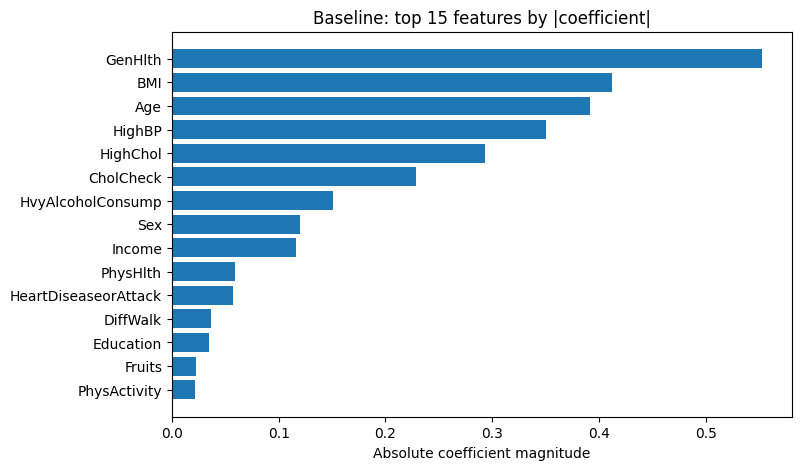

In [17]:

# --- Baseline feature importance via coefficient magnitude ---
# For binary logistic regression, coef_ has shape (1, n_features).
coefs = baseline.named_steps["model"].coef_.ravel()

importance = pd.DataFrame({
    "feature": X.columns,
    "coef": coefs,
    "abs_coef": np.abs(coefs),
}).sort_values("abs_coef", ascending=False)

display(importance.head(15))

# Plot the top 15 features by absolute coefficient
topk = 15
top = importance.head(topk).sort_values("abs_coef")  # sort for nicer horizontal plot

plt.figure(figsize=(8, 5))
plt.barh(top["feature"], top["abs_coef"])
plt.xlabel("Absolute coefficient magnitude")
plt.title(f"Baseline: top {topk} features by |coefficient|")
plt.show()

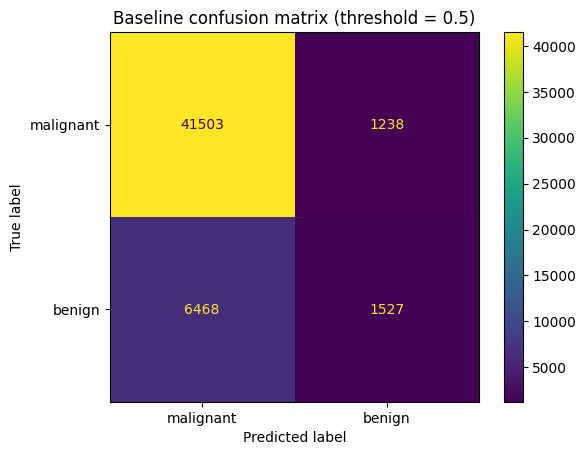

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, pred, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["malignant", "benign"]
)
disp.plot()

plt.title("Baseline confusion matrix (threshold = 0.5)")
plt.show()

# 3. RFE
Now we apply RFE to keep a fixed-size subset (here: 10 features).

Key choices:

n_features_to_select: how many features you want to keep.
step: how many features to drop per iteration. step=1 is thorough but can be slower.
estimator: must expose feature importance (for Logistic Regression we use coef_).
Important: RFE must happen inside a Pipeline so that feature selection is learned using only training data (no leakage).

In [36]:
from sklearn.feature_selection import RFE

rfe_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("select", RFE(
        estimator=LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
        n_features_to_select=7,
        step=1  # remove one feature per iteration (more thorough, slower)
    )),
    ("model", LogisticRegression(max_iter=5000, solver="liblinear", random_state=42))
])

rfe_pipeline.fit(X_train, y_train)

proba_rfe = rfe_pipeline.predict_proba(X_test)[:, 1]
pred_rfe = (proba_rfe >= 0.5).astype(int)

rfe_metrics = {
    "accuracy": accuracy_score(y_test, pred_rfe),
    "precision": precision_score(y_test, pred_rfe),
    "recall": recall_score(y_test, pred_rfe),
    "f1": f1_score(y_test, pred_rfe),
    "ROC-AUC": roc_auc_score(y_test, proba_rfe)
}

rfe_metrics


{'accuracy': 0.847445600756859,
 'precision': 0.5493230174081238,
 'recall': 0.17761100687929957,
 'f1': 0.2684310018903592,
 'ROC-AUC': 0.8125465983212672}

In [37]:
results["B_RFE"] = rfe_metrics

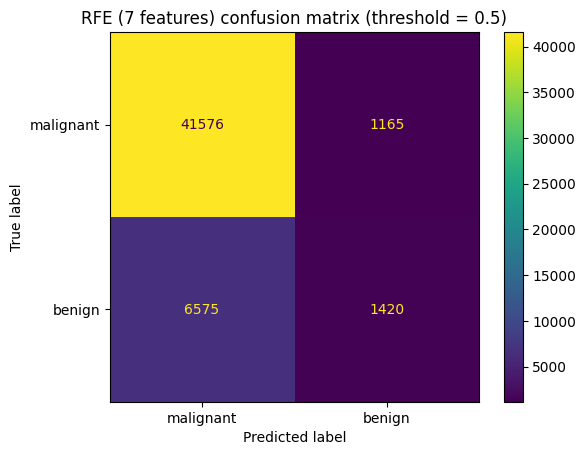

In [38]:

# Confusion matrix for the RFE-selected model
cm = confusion_matrix(y_test, pred_rfe, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["malignant", "benign"]
)
disp.plot()

plt.title("RFE (7 features) confusion matrix (threshold = 0.5)")
plt.show()

In [39]:


# Compare metrics side by side
comparison = pd.DataFrame(
    [baseline_metrics, rfe_metrics],
    index=["Baseline (all features)", "RFE (7 features)"]
)
display(comparison)

# Inspect which features were selected
selector = rfe_pipeline.named_steps["select"]

# support_ is a boolean mask of selected features
selected_mask = selector.support_

# ranking_: 1 means "kept", higher numbers were eliminated earlier
ranking = selector.ranking_

ranking_table = pd.DataFrame({
    "feature": X.columns,
    "selected": selected_mask,
    "rank (1 = kept)": ranking,
}).sort_values(["rank (1 = kept)", "feature"])

display(ranking_table)

selected_features = X.columns[selected_mask].tolist()
print("Selected features:", selected_features)

,accuracy,precision,recall,f1,ROC-AUC
Baseline (all features),0.848116,0.552260,0.190994,0.283829,0.817190
RFE (7 features),0.847446,0.549323,0.177611,0.268431,0.812547


,feature,selected,rank (1 = kept)
18,Age,True,1
3,BMI,True,1
2,CholCheck,True,1
13,GenHlth,True,1
0,HighBP,True,1
1,HighChol,True,1
10,HvyAlcoholConsump,True,1
20,Income,False,2
17,Sex,False,3
6,HeartDiseaseorAttack,False,4


Selected features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HvyAlcoholConsump', 'GenHlth', 'Age']


# 4. CRFE
Instead of choosing “7 features” up front, RFECV tries different subset sizes and uses cross-validation to pick the best number.

We’ll use:

StratifiedKFold to preserve class proportions in each fold.
scoring="roc_auc" so selection is driven by discrimination performance.
min_features_to_select=1 to allow full exploration down to a single feature.
RFECV is more principled than picking an arbitrary feature count, but it’s also more computationally expensive.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV

# RFECV: RFE + cross-validation to choose the number of features automatically
#
# We use StratifiedKFold to keep class proportions similar across folds.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rfecv_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("select", RFECV(
        estimator=LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
        step=1,
        cv=cv,
        scoring="roc_auc",
        min_features_to_select=1
    )),
    ("model", LogisticRegression(max_iter=5000, solver="liblinear", random_state=42))
])

rfecv_pipeline.fit(X_train, y_train)

proba_rfecv = rfecv_pipeline.predict_proba(X_test)[:, 1]
pred_rfecv = (proba_rfecv >= 0.5).astype(int)

rfecv_metrics = {
    "accuracy": accuracy_score(y_test, pred_rfecv),
    "precision": precision_score(y_test, pred_rfecv),
    "recall": recall_score(y_test, pred_rfecv),
    "f1": f1_score(y_test, pred_rfecv),
    "ROC-AUC": roc_auc_score(y_test, proba_rfecv)
}

rfecv_metrics
results["C_RFECV"] = rfecv_metrics

KeyboardInterrupt: 

Optimal number of features (by CV): 21
Selected features: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


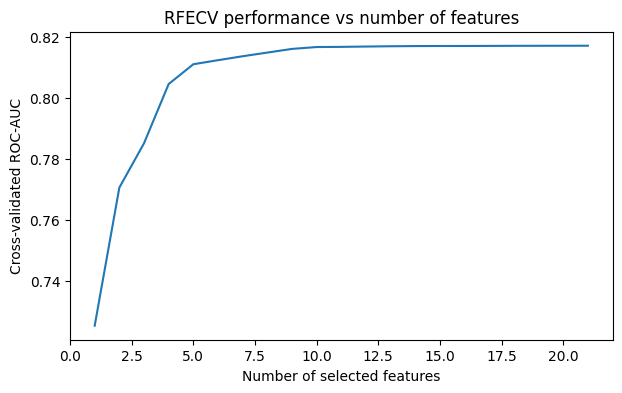

In [29]:

# Extract RFECV results and plot CV score vs number of selected features
rfecv_selector = rfecv_pipeline.named_steps["select"]

print("Optimal number of features (by CV):", rfecv_selector.n_features_)

opt_features = X.columns[rfecv_selector.support_].tolist()
print("Selected features:", opt_features)

# scikit-learn stores RFECV scores differently across versions; handle common cases.
scores = None
n_features = None

if hasattr(rfecv_selector, "cv_results_") and "mean_test_score" in rfecv_selector.cv_results_:
    scores = rfecv_selector.cv_results_["mean_test_score"]
    n_features = rfecv_selector.cv_results_["n_features"]
elif hasattr(rfecv_selector, "grid_scores_"):
    scores = rfecv_selector.grid_scores_
    n_features = np.arange(1, len(scores) + 1)

plt.figure(figsize=(7, 4))
plt.plot(n_features, scores)
plt.xlabel("Number of selected features")
plt.ylabel("Cross-validated ROC-AUC")
plt.title("RFECV performance vs number of features")
plt.show()

In [41]:

# Final comparison table across all approaches
comparison2 = pd.DataFrame(
    [baseline_metrics, rfe_metrics, rfecv_metrics],
    index=["Baseline (all features)", "RFE (7 features)", "RFECV (auto)"]
)
display(comparison2)

,accuracy,precision,recall,f1,ROC-AUC
Baseline (all features),0.848116,0.552260,0.190994,0.283829,0.817190
RFE (7 features),0.847446,0.549323,0.177611,0.268431,0.812547
RFECV (auto),0.848116,0.552260,0.190994,0.283829,0.817190


Compared with RFECV, RFE only used 7 features, yet the performance was quite similar. To enhance the interpretability of the model, we chose the 7 features selected by RFE.

# 5. SMOTE Experiments
## 5.1 SMOTE without Feature Engineering (Experiment D)

In [46]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=5000, solver="liblinear", random_state=42))
])

smote_pipeline.fit(X_train_smote, y_train_smote)

proba_smote = smote_pipeline.predict_proba(X_test)[:, 1]
pred_smote = (proba_smote >= 0.5).astype(int)

smote_metrics = {
    "accuracy": accuracy_score(y_test, pred_smote),
    "precision": precision_score(y_test, pred_smote),
    "recall": recall_score(y_test, pred_smote),
    "f1": f1_score(y_test, pred_smote),
    "ROC-AUC": roc_auc_score(y_test, proba_smote)
}

smote_metrics
results["D_smote"] = smote_metrics

# 6. Results Comparison

In [48]:
results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1,ROC-AUC
A_baseline,0.848116,0.552260,0.190994,0.283829,0.817190
B_RFE,0.847446,0.549323,0.177611,0.268431,0.812547
C_RFECV,0.848116,0.552260,0.190994,0.283829,0.817190
D_smote,0.729857,0.339190,0.753346,0.467769,0.814971


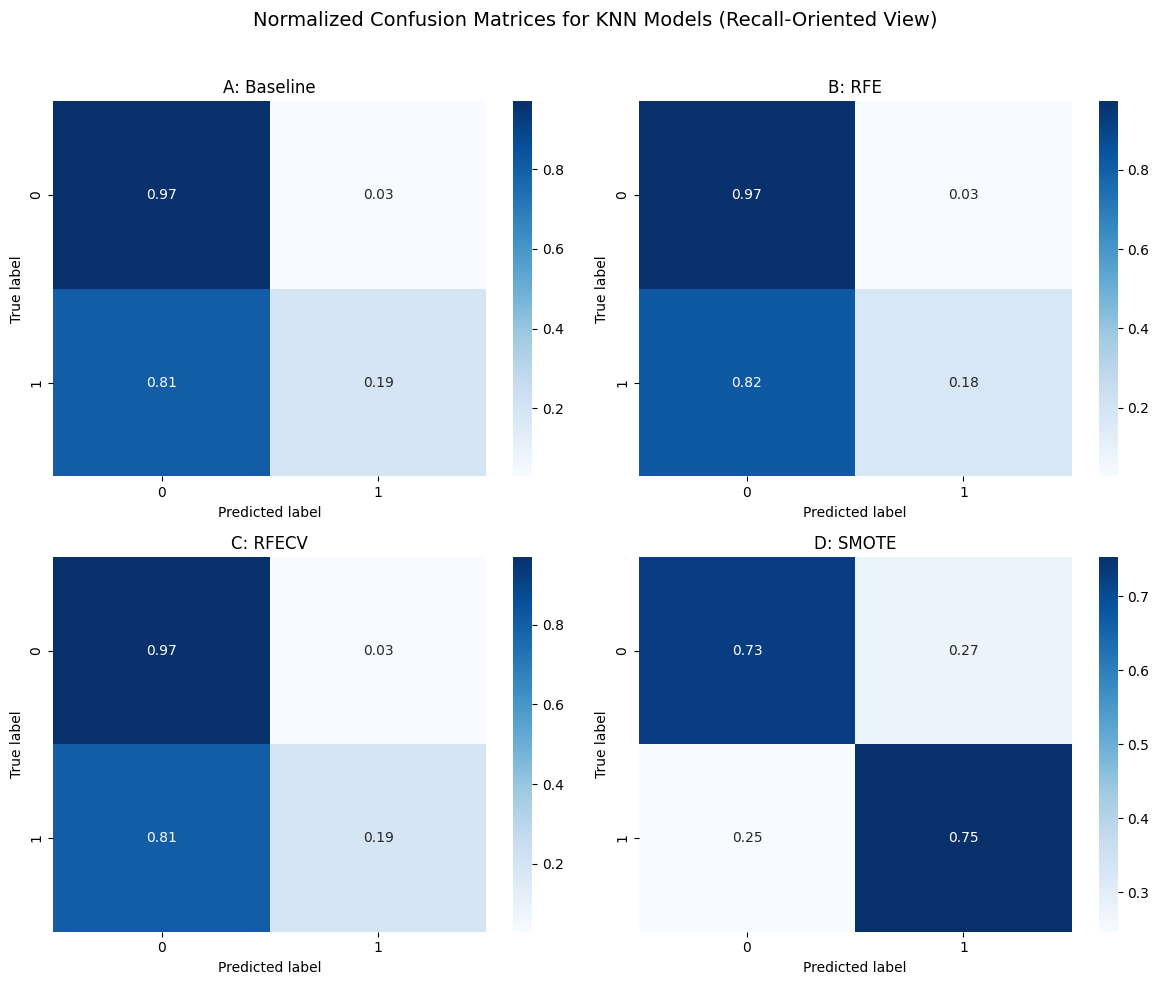

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

models = {
    "A: Baseline": (pred),
    "B: RFE": (pred_rfe),
    "C: RFECV": (pred_rfecv),
    "D: SMOTE": (pred_smote)
}


fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, pred) in zip(axes, models.items()):
    y_pred = pred
    cm = confusion_matrix(y_test, y_pred, normalize="true")

    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        ax=ax
    )
    
    ax.set_title(name)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

plt.suptitle("Normalized Confusion Matrices for KNN Models (Recall-Oriented View)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# 7. Discussion
Although SMOTE slightly reduces overall accuracy, it significantly lowers the false negative rate, which is critical for imbalanced classification tasks. Therefore, the SMOTE-based model is selected as the final model due to its superior ability to identify minority-class instances.
The changes brought by FE are not obvious and have been somewhat inconsistent. To be on an explainable side, we choose 7 features RFE.

In [51]:
from sklearn.feature_selection import RFE

rfe_smote_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("select", RFE(
        estimator=LogisticRegression(max_iter=5000, solver="liblinear", random_state=42),
        n_features_to_select=7,
        step=1  # remove one feature per iteration (more thorough, slower)
    )),
    ("model", LogisticRegression(max_iter=5000, solver="liblinear", random_state=42))
])

rfe_smote_pipeline.fit(X_train_smote, y_train_smote)

proba_rfe_smote = rfe_smote_pipeline.predict_proba(X_test)[:, 1]
pred_rfe_smote = (proba_rfe_smote >= 0.5).astype(int)

rfe_smote_metrics = {
    "accuracy": accuracy_score(y_test, pred_rfe_smote),
    "precision": precision_score(y_test, pred_rfe_smote),
    "recall": recall_score(y_test, pred_rfe_smote),
    "f1": f1_score(y_test, pred_rfe_smote),
    "ROC-AUC": roc_auc_score(y_test, proba_rfe_smote)
}

rfe_smote_metrics

{'accuracy': 0.7274716177861873,
 'precision': 0.3361429534726905,
 'recall': 0.7482176360225141,
 'f1': 0.4638827497964406,
 'ROC-AUC': 0.8124265360335599}

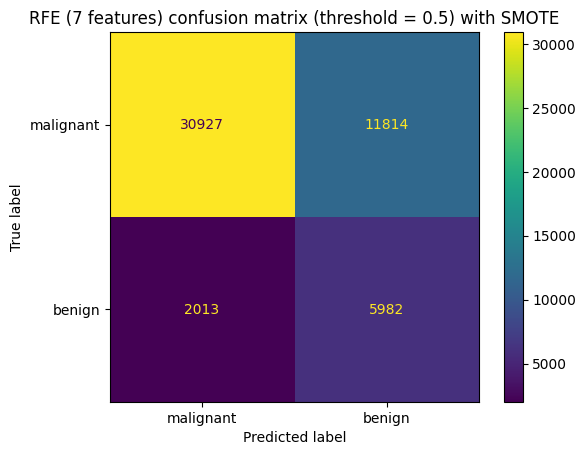

In [52]:
# Confusion matrix for the RFE-selected model
cm = confusion_matrix(y_test, pred_rfe_smote, labels=[0, 1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["malignant", "benign"]
)
disp.plot()

plt.title("RFE (7 features) confusion matrix (threshold = 0.5) with SMOTE")
plt.show()

In [53]:

selected_features = X_train_smote.columns[rfe_smote_pipeline.named_steps['select'].support_].tolist()
X_train_smote_rfe = X_train_smote[selected_features]
X_train_smote_rfe.to_csv("X_train_smote_rfe.csv", index=False)
y_train_smote.to_csv("y_train_smote.csv", index=False)


X_test_rfe = X_test[selected_features]
X_test_rfe.to_csv("X_test_rfe.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("SMOTE + RFE datasets saved successfully!")

SMOTE + RFE datasets saved successfully!
